<a href="https://colab.research.google.com/github/Sonia1895/PROCESAMIENTO_CLASIFICACION_DATOS/blob/main/Tarea_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset: tweet_sentiment_multilingual (configuracion "spanish"), CardiffNLP.
Fuente: https://huggingface.co/datasets/cardiffnlp/tweet_sentiment_multilingual


Descripción del dataset:
    Tweets en espanol etiquetados con sentimiento: negativo (0), neutral (1),
    positivo (2). Viene dividido en train / validation / test.

#Carga de datos

In [3]:
!pip install -q datasets==2.21.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 11.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [1]:
import pandas as pd
from datasets import load_dataset

# Se cargan las particiones train y test del subconjunto en español.
dataset = load_dataset("cardiffnlp/tweet_sentiment_multilingual", "spanish")

df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

# Mapeo de la etiqueta numerica a su nombre legible.
label_map = {0: "negativo", 1: "neutral", 2: "positivo"}
df_train["label_name"] = df_train["label"].map(label_map)
df_test["label_name"] = df_test["label"].map(label_map)

print("Tamaño de entrenamiento:", df_train.shape)
print("Tamaño de prueba:", df_test.shape)
df_train.head()

Generating train split:   0%|          | 0/1839 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/324 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/870 [00:00<?, ? examples/s]

Tamaño de entrenamiento: (1839, 3)
Tamaño de prueba: (870, 3)


,text,label,label_name
0,estoy hasta el ojete de que me digáis que teng...,0,negativo
1,@user Por? Tenía pensado verla después de la ...,1,neutral
2,Esto de estar feliz mola,2,positivo
3,Ya no es tan divertido,0,negativo
4,@user te recuerdo que soy una persona que tien...,1,neutral


#Exploración y estadisticas descriptivas

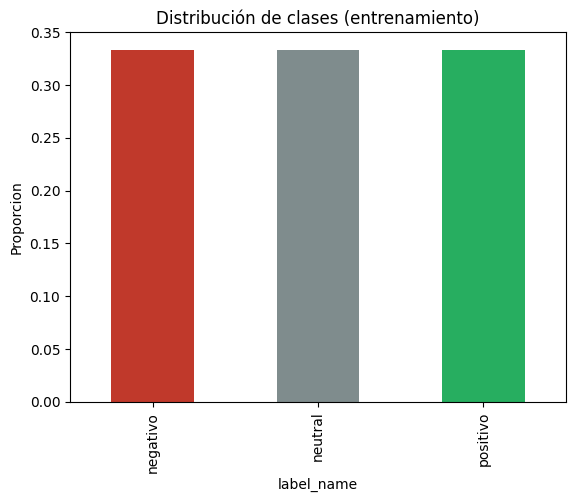

negativo
count    613.000000
mean      16.244698
std        6.266064
min        5.000000
25%       11.000000
50%       17.000000
75%       21.000000
max       31.000000
Name: conteo_palabras, dtype: float64

neutral
count    613.000000
mean      15.391517
std        6.209843
min        5.000000
25%       10.000000
50%       15.000000
75%       20.000000
max       30.000000
Name: conteo_palabras, dtype: float64

positivo
count    613.000000
mean      14.903752
std        5.788105
min        5.000000
25%       10.000000
50%       14.000000
75%       19.000000
max       30.000000
Name: conteo_palabras, dtype: float64



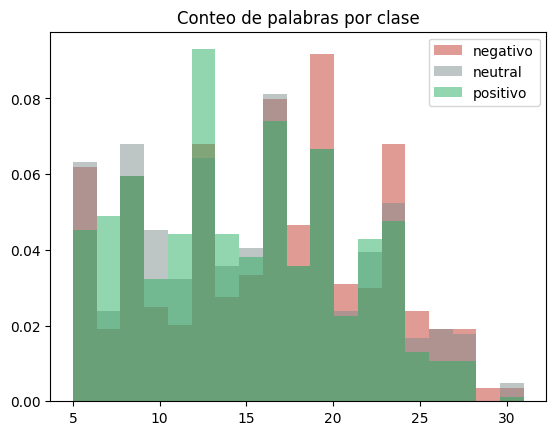

In [3]:
# Distribución de clases
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
df_train["label_name"].value_counts(normalize=True).plot.bar(color=["#c0392b", "#7f8c8d", "#27ae60"])
plt.title("Distribución de clases (entrenamiento)")
plt.ylabel("Proporcion")
plt.show()

# Conteo de palabras y caracteres por tweet.
df_train["conteo_palabras"] = df_train["text"].apply(lambda x: len(str(x).split()))
df_train["conteo_caracteres"] = df_train["text"].apply(lambda x: len(str(x)))
df_train["densidad_palarbas"] = df_train["conteo_caracteres"] / df_train["conteo_palabras"]

for clase in label_map.values():
    print(clase)
    print(df_train[df_train["label_name"] == clase]["conteo_palabras"].describe())
    print()

# Histogramas comparativos por clase.
plt.figure()
plt.title("Conteo de palabras por clase")
bins = np.linspace(df_train["conteo_palabras"].min(), df_train["conteo_palabras"].max(), 20)
colores = {"negativo": "#c0392b", "neutral": "#7f8c8d", "positivo": "#27ae60"}
for clase, color in colores.items():
    subset = df_train[df_train["label_name"] == clase]["conteo_palabras"]
    plt.hist(subset, bins=bins, label=clase, color=color, alpha=0.5, density=True)
plt.legend()
plt.show()


#Preprocesamiento en español

In [5]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 49.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [7]:
# Se usa spaCy (es_core_news_sm) para lematizar. Se eliminan stopwords y caracteres que no sean letras.
import spacy
import re

nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])


def limpiar_texto(texto):
    """Limpia, elimina stopwords y lematiza un texto en espanol."""
    # Quita menciones (@usuario), URLs y caracteres que no sean letras.
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"http\S+", " ", texto)
    texto = re.sub(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ\s]", " ", texto)
    texto = texto.lower()

    doc = nlp(texto)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_space and len(token.lemma_) > 1
    ]
    return " ".join(tokens)


# nlp.pipe procesa en lote, es más eficiente que aplicar fila por fila.
print("Preprocesando textos de entrenamiento...")
df_train["texto_limpio"] = [limpiar_texto(t) for t in df_train["text"]]
print("Preprocesando textos de prueba...")
df_test["texto_limpio"] = [limpiar_texto(t) for t in df_test["text"]]

df_train[["text", "texto_limpio"]].head()

Preprocesando textos de entrenamiento...
Preprocesando textos de prueba...


,text,texto_limpio
0,estoy hasta el ojete de que me digáis que teng...,ojete digáis cara malo leche
1,@user Por? Tenía pensado verla después de la ...,pensado ver él daredevil
2,Esto de estar feliz mola,feliz molo
3,Ya no es tan divertido,divertido
4,@user te recuerdo que soy una persona que tien...,recordar persona criterio equivocado


#Preparación de conjuntos X / y

In [8]:
X_train, y_train = df_train["texto_limpio"], df_train["label"]
X_test, y_test = df_test["texto_limpio"], df_test["label"]

#Vectorización (4 representaciones)

In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

vectorizadores = {
    "conteo": CountVectorizer(analyzer="word", max_features=5000),
    "tfidf_palabras": TfidfVectorizer(analyzer="word", max_features=5000),
    "tfidf_ngramas": TfidfVectorizer(analyzer="word", ngram_range=(2, 3), max_features=5000),
    "tfidf_caracteres": TfidfVectorizer(analyzer="char", max_features=5000),
}

In [10]:

datos_vectorizados = {}
for nombre, vect in vectorizadores.items():
    xtrain = vect.fit_transform(X_train)
    xtest = vect.transform(X_test)
    datos_vectorizados[nombre] = (xtrain, xtest)

In [11]:
datos_vectorizados

{'conteo': (<Compressed Sparse Row sparse matrix of dtype 'int64'
  	with 10496 stored elements and shape (1839, 4729)>,
  <Compressed Sparse Row sparse matrix of dtype 'int64'
  	with 3434 stored elements and shape (870, 4729)>),
 'tfidf_palabras': (<Compressed Sparse Row sparse matrix of dtype 'float64'
  	with 10496 stored elements and shape (1839, 4729)>,
  <Compressed Sparse Row sparse matrix of dtype 'float64'
  	with 3434 stored elements and shape (870, 4729)>),
 'tfidf_ngramas': (<Compressed Sparse Row sparse matrix of dtype 'float64'
  	with 5200 stored elements and shape (1839, 5000)>,
  <Compressed Sparse Row sparse matrix of dtype 'float64'
  	with 84 stored elements and shape (870, 5000)>),
 'tfidf_caracteres': (<Compressed Sparse Row sparse matrix of dtype 'float64'
  	with 28365 stored elements and shape (1839, 34)>,
  <Compressed Sparse Row sparse matrix of dtype 'float64'
  	with 13428 stored elements and shape (870, 34)>)}

#Diseño de experimentos: modelos x vectorizaciones x hiperparametros

In [13]:
# Para cada modelo se define una malla (grid) de hiperparametros razonable.
# GridSearchCV hace validacion cruzada (cv=3) para elegir la mejor
# combinacion de hiperparametros dentro de cada vectorizacion.

import time
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modelos = {
    "regresion_logistica": (
        LogisticRegression(max_iter=1000),
        {"C": [0.1, 1, 10]},
    ),
    "naive_bayes": (
        MultinomialNB(),
        {"alpha": [0.1, 0.5, 1.0]},
    ),
    "svm_lineal": (
        LinearSVC(max_iter=5000),
        {"C": [0.1, 1, 10]},
    ),
    "random_forest": (
        RandomForestClassifier(random_state=42),
        {"n_estimators": [100, 200], "max_depth": [None, 20]},
    ),
}

resultados = []

for nombre_vect, (xtrain, xtest) in datos_vectorizados.items():
    for nombre_modelo, (modelo, grid_params) in modelos.items():
        inicio = time.time()

        grid = GridSearchCV(modelo, grid_params, cv=3, scoring="f1_macro", n_jobs=-1)
        grid.fit(xtrain, y_train)

        mejor_modelo = grid.best_estimator_
        predicciones = mejor_modelo.predict(xtest)

        duracion = time.time() - inicio

        resultados.append({
            "vectorizacion": nombre_vect,
            "modelo": nombre_modelo,
            "mejores_hiperparametros": grid.best_params_,
            "accuracy": accuracy_score(y_test, predicciones),
            "precision_macro": precision_score(y_test, predicciones, average="macro"),
            "recall_macro": recall_score(y_test, predicciones, average="macro"),
            "f1_macro": f1_score(y_test, predicciones, average="macro"),
            "tiempo_seg": round(duracion, 2),
        })

        print(f"{nombre_vect} + {nombre_modelo}: "
              f"F1={resultados[-1]['f1_macro']:.3f}, "
              f"params={grid.best_params_}, "
              f"tiempo={duracion:.1f}s")

conteo + regresion_logistica: F1=0.515, params={'C': 0.1}, tiempo=12.9s
conteo + naive_bayes: F1=0.508, params={'alpha': 1.0}, tiempo=0.2s
conteo + svm_lineal: F1=0.507, params={'C': 0.1}, tiempo=0.4s
conteo + random_forest: F1=0.509, params={'max_depth': 20, 'n_estimators': 100}, tiempo=43.5s
tfidf_palabras + regresion_logistica: F1=0.513, params={'C': 1}, tiempo=0.7s
tfidf_palabras + naive_bayes: F1=0.515, params={'alpha': 1.0}, tiempo=0.1s
tfidf_palabras + svm_lineal: F1=0.513, params={'C': 0.1}, tiempo=0.2s
tfidf_palabras + random_forest: F1=0.474, params={'max_depth': 20, 'n_estimators': 200}, tiempo=29.8s
tfidf_ngramas + regresion_logistica: F1=0.227, params={'C': 0.1}, tiempo=0.4s
tfidf_ngramas + naive_bayes: F1=0.227, params={'alpha': 0.1}, tiempo=0.1s
tfidf_ngramas + svm_lineal: F1=0.227, params={'C': 1}, tiempo=0.3s
tfidf_ngramas + random_forest: F1=0.195, params={'max_depth': None, 'n_estimators': 100}, tiempo=33.5s
tfidf_caracteres + regresion_logistica: F1=0.381, params={'

#Tabla comparativa de resultados

In [14]:

df_resultados = pd.DataFrame(resultados).sort_values("f1_macro", ascending=False)
df_resultados.reset_index(drop=True, inplace=True)
print(df_resultados)

       vectorizacion               modelo  \
0             conteo  regresion_logistica   
1     tfidf_palabras          naive_bayes   
2     tfidf_palabras           svm_lineal   
3     tfidf_palabras  regresion_logistica   
4             conteo        random_forest   
5             conteo          naive_bayes   
6             conteo           svm_lineal   
7     tfidf_palabras        random_forest   
8   tfidf_caracteres          naive_bayes   
9   tfidf_caracteres           svm_lineal   
10  tfidf_caracteres  regresion_logistica   
11  tfidf_caracteres        random_forest   
12     tfidf_ngramas          naive_bayes   
13     tfidf_ngramas  regresion_logistica   
14     tfidf_ngramas           svm_lineal   
15     tfidf_ngramas        random_forest   

                     mejores_hiperparametros  accuracy  precision_macro  \
0                                 {'C': 0.1}  0.514943         0.515691   
1                             {'alpha': 1.0}  0.518391         0.515935   
2        

#Gráficas comparativas

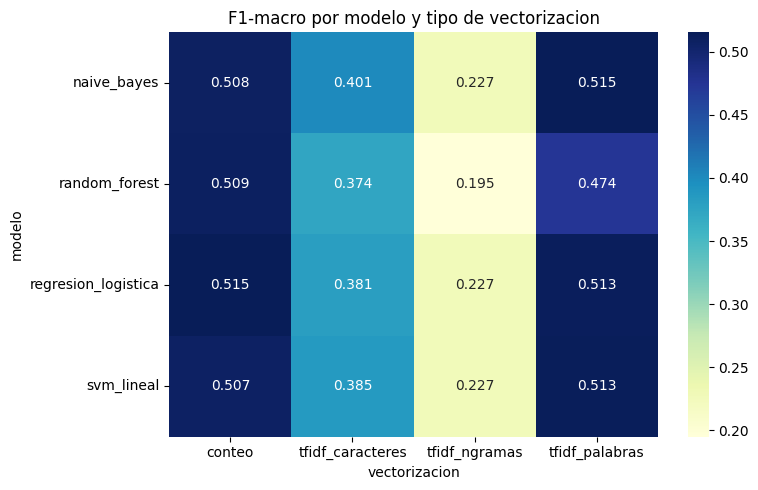

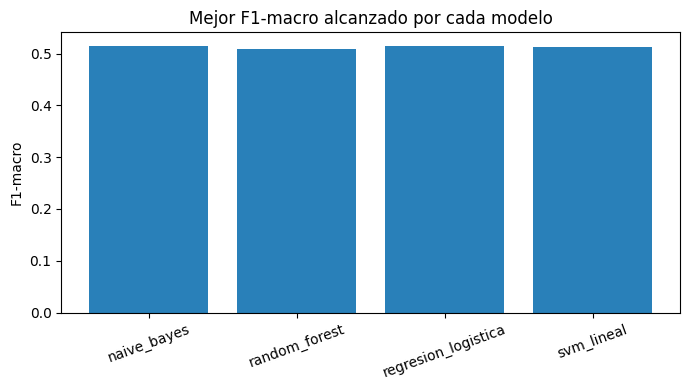

In [15]:
import seaborn as sns

# Heatmap de F1-macro por combinacion modelo x vectorizacion.
tabla_f1 = df_resultados.pivot(index="modelo", columns="vectorizacion", values="f1_macro")

plt.figure(figsize=(8, 5))
sns.heatmap(tabla_f1, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("F1-macro por modelo y tipo de vectorizacion")
plt.tight_layout()
plt.show()

# Barras del mejor resultado por modelo.
mejor_por_modelo = df_resultados.loc[df_resultados.groupby("modelo")["f1_macro"].idxmax()]

plt.figure(figsize=(7, 4))
plt.bar(mejor_por_modelo["modelo"], mejor_por_modelo["f1_macro"], color="#2980b9")
plt.title("Mejor F1-macro alcanzado por cada modelo")
plt.ylabel("F1-macro")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#Matriz de confusion del mejor modelo global

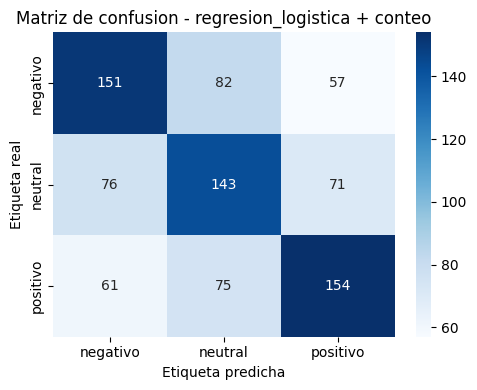


Mejor combinacion encontrada:
vectorizacion                           conteo
modelo                     regresion_logistica
mejores_hiperparametros             {'C': 0.1}
accuracy                              0.514943
precision_macro                       0.515691
recall_macro                          0.514943
f1_macro                              0.515233
tiempo_seg                               12.91
Name: 0, dtype: object


In [16]:
from sklearn.metrics import confusion_matrix

mejor_fila = df_resultados.iloc[0]
mejor_vect_nombre = mejor_fila["vectorizacion"]
mejor_modelo_nombre = mejor_fila["modelo"]

xtrain_final, xtest_final = datos_vectorizados[mejor_vect_nombre]
modelo_final, grid_params_final = modelos[mejor_modelo_nombre]
grid_final = GridSearchCV(modelo_final, grid_params_final, cv=3, scoring="f1_macro", n_jobs=-1)
grid_final.fit(xtrain_final, y_train)
pred_final = grid_final.predict(xtest_final)

matriz = confusion_matrix(y_test, pred_final)
df_matriz = pd.DataFrame(matriz, index=label_map.values(), columns=label_map.values())

plt.figure(figsize=(5, 4))
sns.heatmap(df_matriz, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusion - {mejor_modelo_nombre} + {mejor_vect_nombre}")
plt.ylabel("Etiqueta real")
plt.xlabel("Etiqueta predicha")
plt.tight_layout()
plt.show()

print("\nMejor combinacion encontrada:")
print(mejor_fila)